In [1]:
# !pip install ripser persim scikit-learn numpy matplotlib seaborn
import numpy as np
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
import os

In [2]:
os.chdir('../..')
!pwd

/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results


(3122, 103) (3122, 3) (3122,)


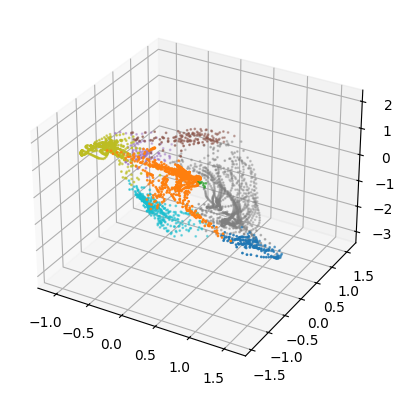

In [3]:
# ---- 1) Load your 3D time series ----
# X shape: (n_samples, 3)
# Replace this with your data:
# X = np.loadtxt('your_xyz.csv', delimiter=',')
# For demo, make a noisy 3D circle (one loop):
t = np.linspace(0, 4*np.pi, 200)
X = np.column_stack([np.cos(t), np.sin(t), 0.1*np.sin(3*t)]) + 0.02*np.random.randn(len(t),3)


Y = np.loadtxt('data/generated/comparable_embeddings/Y0__BunDLeNet_worm_0')
B = np.loadtxt('data/generated/comparable_embeddings/B__BunDLeNet_worm_0')
X = np.load('data/raw/c_elegans/neural_data_worm_0.npy')[-3122:]
print(X.shape, Y.shape, B.shape)
#X = X[np.random.randint(X.shape[0], size=1000),:]


# make a three d plot of X
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y[:,0], Y[:,1], Y[:,2], s=1, c=B, cmap='tab10')
plt.show()

(12488, 3)


<IPython.core.display.Javascript object>


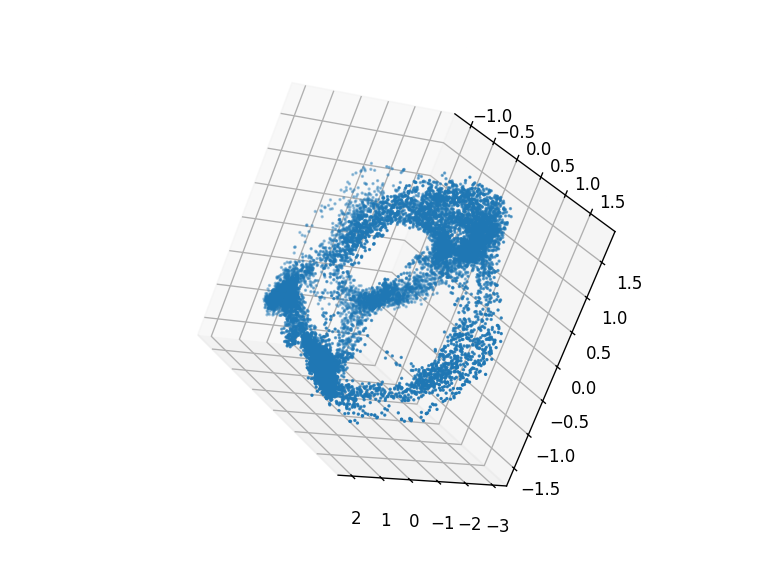

/tmp/ipykernel_998567/3452631087.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(Y_augmented[:,0], Y_augmented[:,1], Y_augmented[:,2], s=1, cmap='tab10')


In [17]:
%matplotlib notebook
Y_augmented = Y[..., np.newaxis]  + np.random.normal(scale=0.05, size=(Y.shape[0], Y.shape[1], 4))
Y_augmented = np.transpose(Y_augmented, (2, 0, 1))  # (2, 3000, 3)
Y_augmented = Y_augmented.reshape(-1, 3)    
print(Y_augmented.shape)
# make a three d plot of X
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y_augmented[:,0], Y_augmented[:,1], Y_augmented[:,2], s=1, cmap='tab10')
plt.show()

# RIPSER on manifold Y

<IPython.core.display.Javascript object>


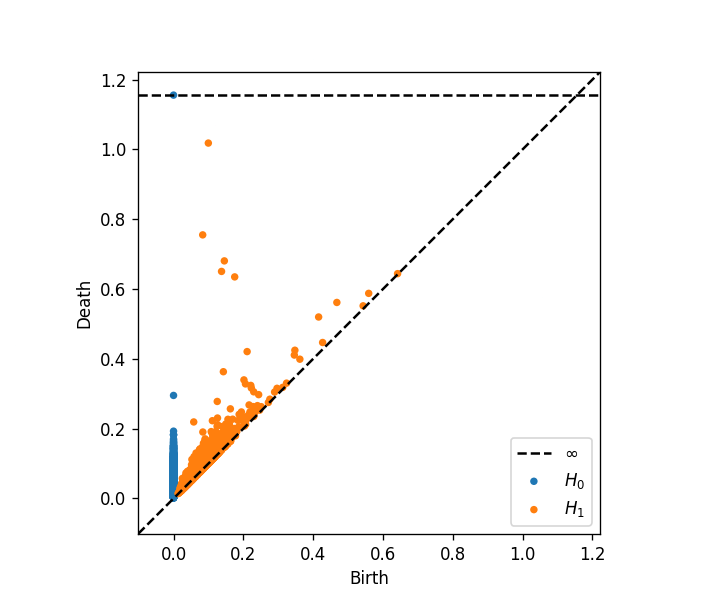

In [18]:
# ---- 2) Persistent homology via Vietoris–Rips ----
res_aug = ripser(Y_augmented, maxdim=1)  # H0, H1

# ---- 3) Visualize diagrams ----
plt.figure(figsize=(6,5))
plot_diagrams(res_aug['dgms'], show=True)


<IPython.core.display.Javascript object>


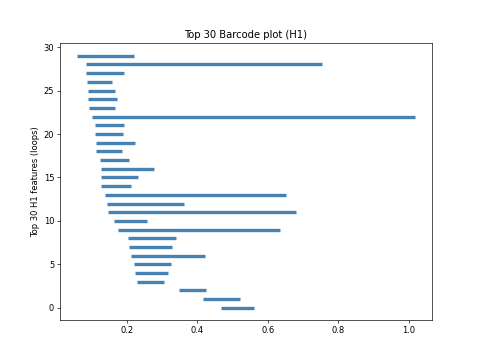

In [74]:
def plot_barcode_diagram(H1, top_n_features=30, max_chance_lifetime=None):
    # Compute persistence length
    lifetimes = H1[:, 1] - H1[:, 0]

    # Take indices of top 30 longest bars
    top_idx = np.sort(np.argsort(lifetimes)[-top_n_features:])
    top_lifetimes = lifetimes[top_idx]
    
    plt.figure(figsize=(8,6))
    for i, idx in enumerate(top_idx):
        birth, death = H1[idx]
        # chance lifetime bar: birth → birth + max_chance_lifetime
        if max_chance_lifetime is not None:
            plt.hlines(
                y=i, xmin=birth, xmax=birth + max_chance_lifetime,
                lw=4, color="lightgray", alpha=0.7
            )
        # actual barcodes    

        plt.hlines(y=i, xmin=birth, xmax=death if death < np.inf else birth+1, lw=4, color="steelblue")


    plt.ylabel("Top 30 H1 features (loops)")
    plt.title("Top 30 Barcode plot (H1)")
    plt.show()
    return fig, top_lifetimes

fig, top_lifetimes = plot_barcode_diagram(res_aug['dgms'][1])


<IPython.core.display.Javascript object>


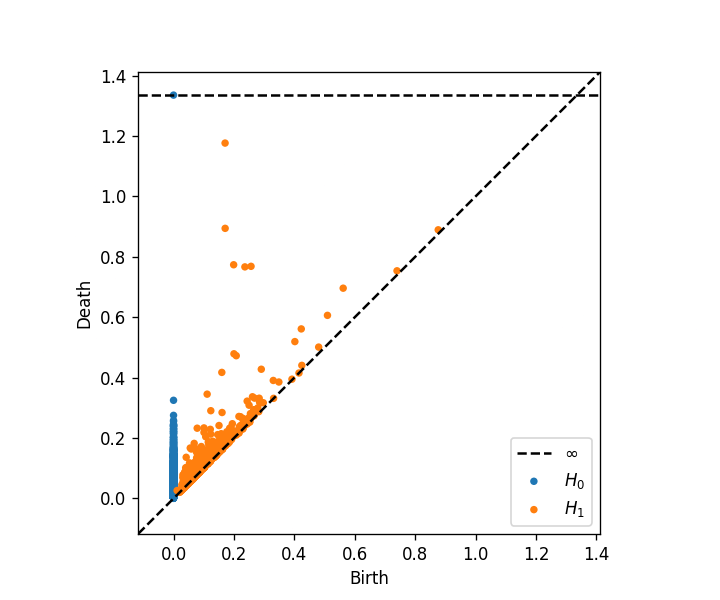

In [20]:
# ---- 2) Persistent homology via Vietoris–Rips ----
res = ripser(Y, maxdim=1)  # H0, H1

# ---- 3) Visualize diagrams ----
plt.figure(figsize=(6,5))
plot_diagrams(res['dgms'], show=True)


<IPython.core.display.Javascript object>


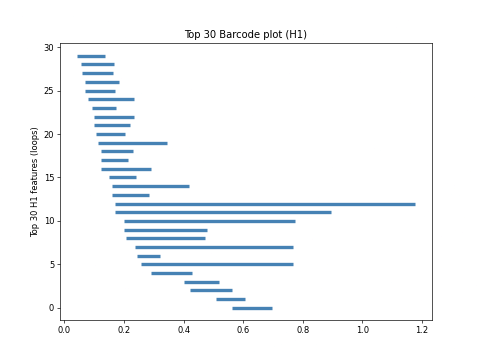

In [75]:
fig, top_lifetimes = plot_barcode_diagram(res['dgms'][1])

# RISPER on shuffled manifold

<IPython.core.display.Javascript object>


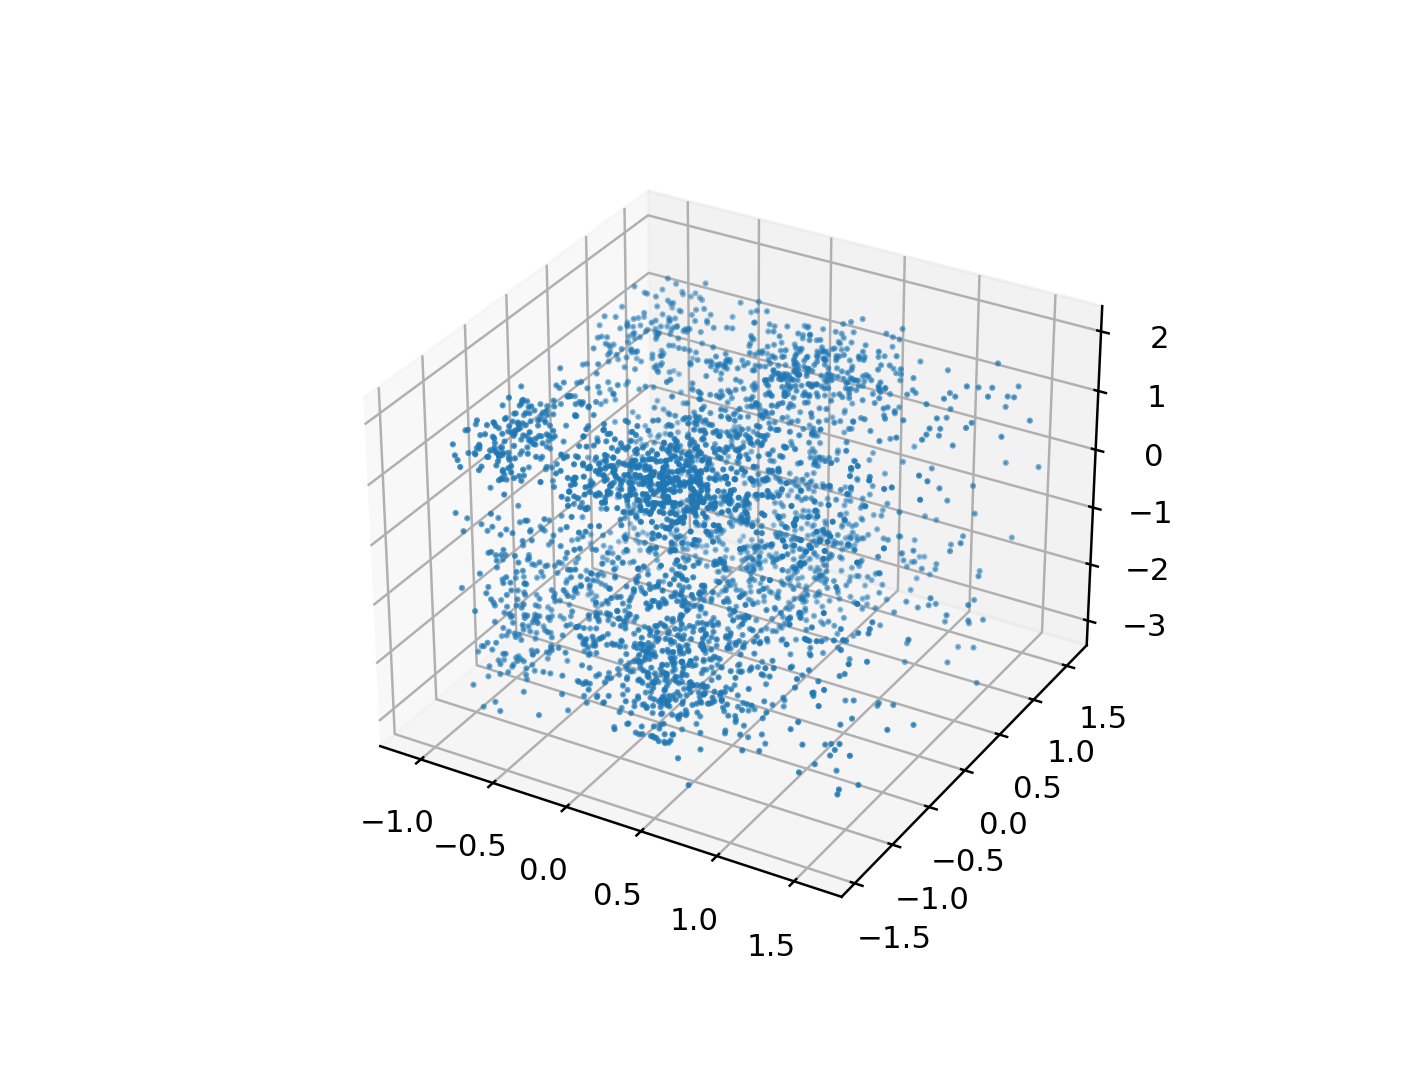

/tmp/ipykernel_998567/2768419199.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(Y_shuffled[:,0], Y_shuffled[:,1], Y_shuffled[:,2], s=1, cmap='tab10')


In [61]:
#X = X[np.random.randint(X.shape[0], size=1000),:]
Y_shuffled = Y.copy()
Y_shuffled[:,0] = np.random.permutation(Y[:,0])
Y_shuffled[:,1] = np.random.permutation(Y[:,1])
Y_shuffled[:,2] = np.random.permutation(Y[:,2])

# make a three d plot of X
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y_shuffled[:,0], Y_shuffled[:,1], Y_shuffled[:,2], s=1, cmap='tab10')
plt.show()

<IPython.core.display.Javascript object>


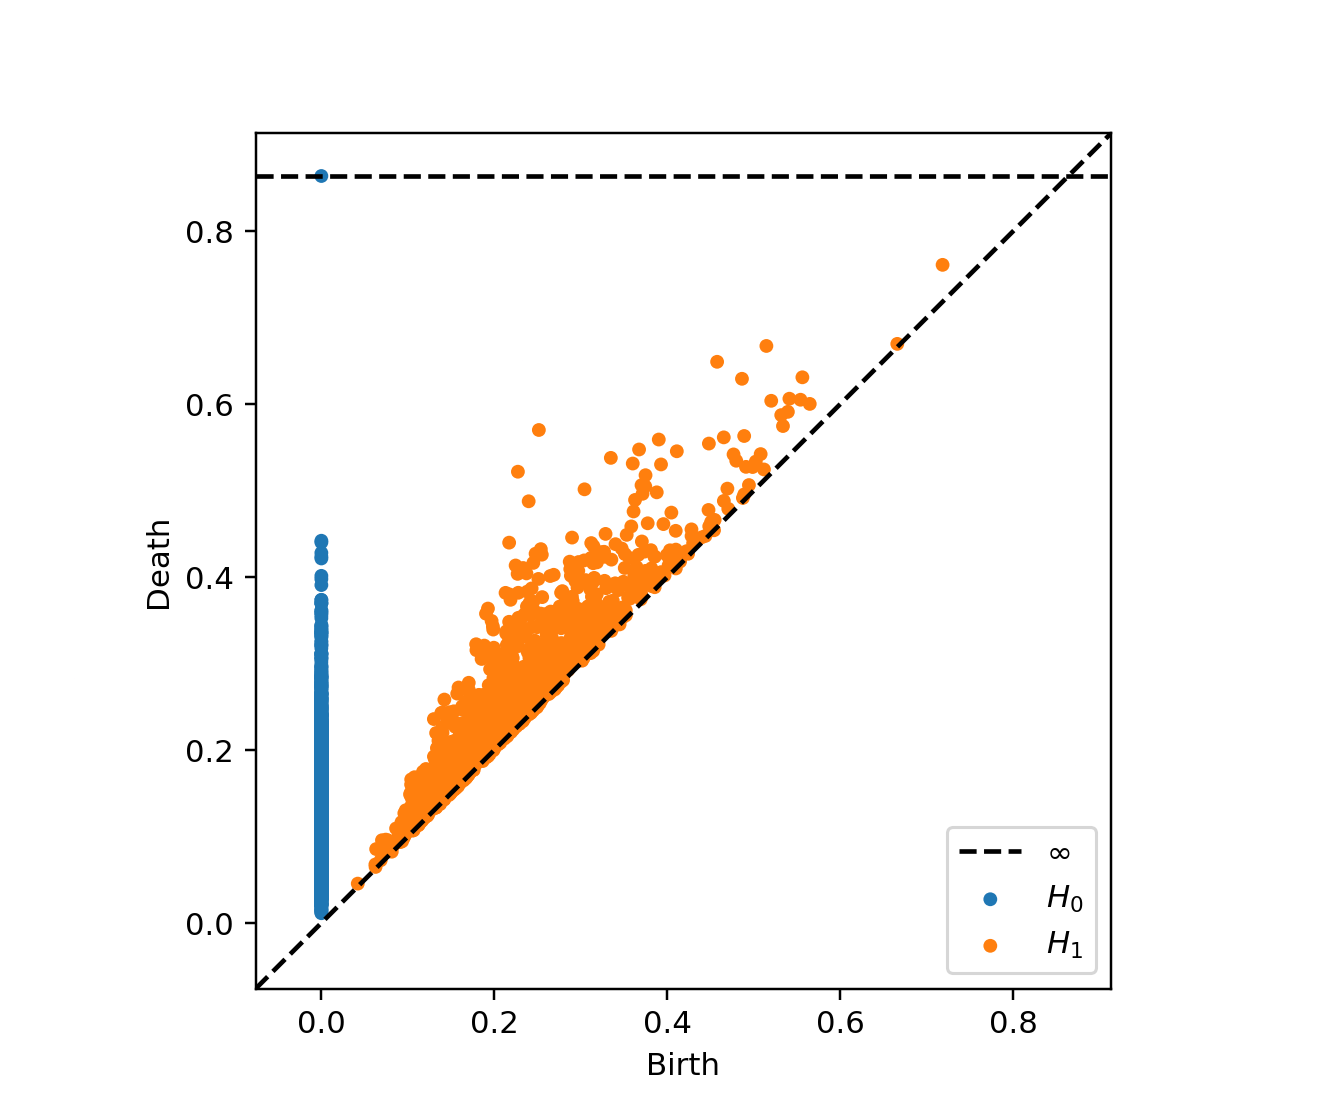

In [62]:
# ---- 2) Persistent homology via Vietoris–Rips ----
res_shuffled = ripser(Y_shuffled, maxdim=1)  # H0, H1


# ---- 3) Visualize diagrams ----
plt.figure(figsize=(6,5))
plot_diagrams(res_shuffled['dgms'], show=True)

<IPython.core.display.Javascript object>


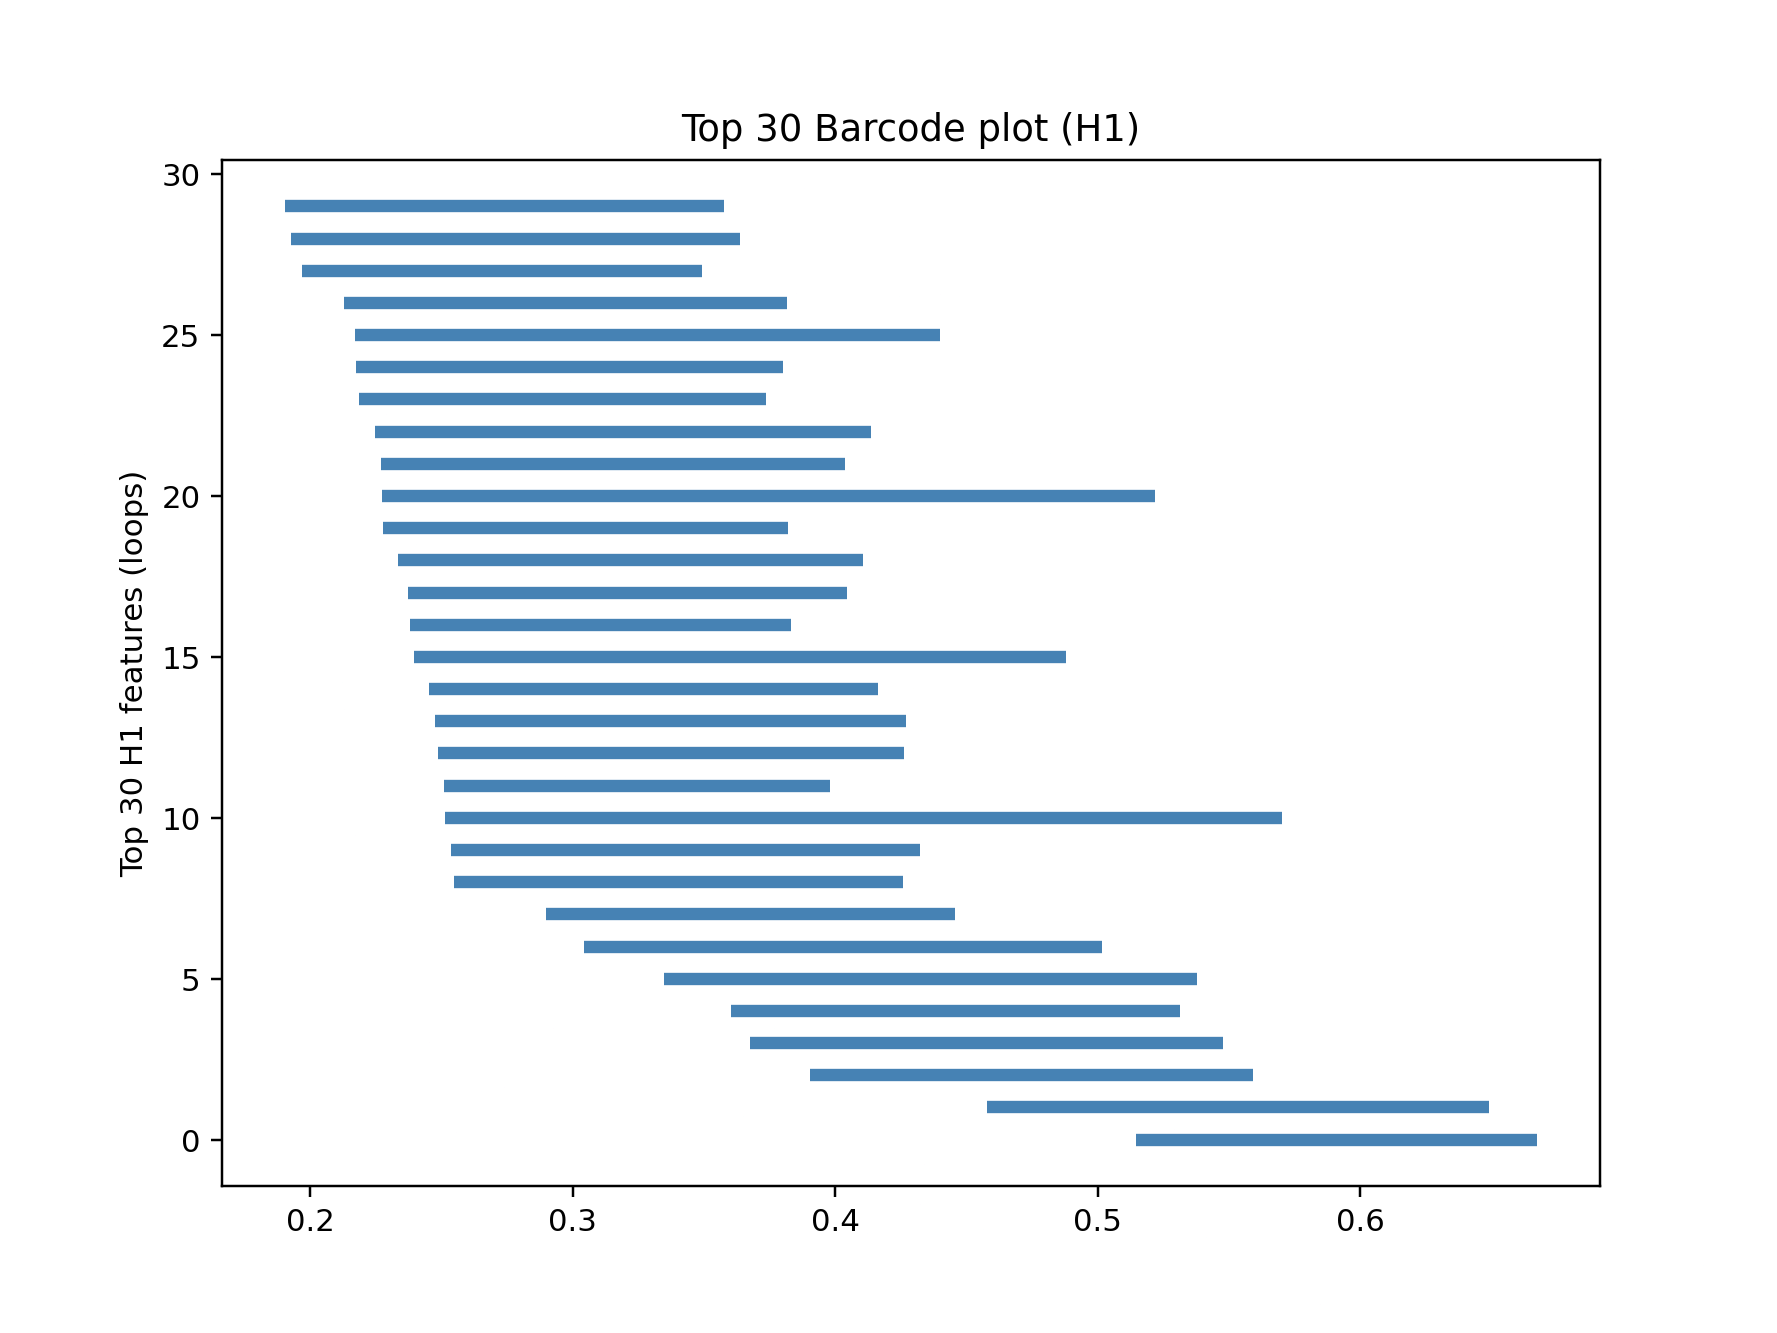

0.318630188703537


In [63]:
fig, lifetimes = plot_barcode_diagram(res_shuffled['dgms'][1])
max_chance_lifetime  = np.max(lifetimes)
print(max_chance_lifetime)

In [77]:
for i in range(500):
    Y[:,0] = np.roll(Y[:,0], shift=np.random.randint(500, Y.shape[0]))
    Y[:,1] = np.roll(Y[:,1], shift=np.random.randint(500, Y.shape[0]))
    Y[:,2] = np.roll(Y[:,2], shift=np.random.randint(500, Y.shape[0]))

    res = ripser(Y, maxdim=1)  # H0, H1
    diagrams = res['dgms']


509

# RIPSER on neural data directly

<IPython.core.display.Javascript object>


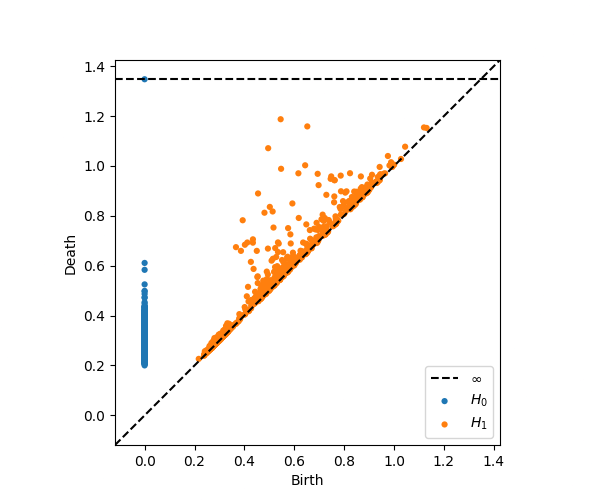

In [68]:
# ---- 2) Persistent homology via Vietoris–Rips ----
res_neural = ripser(X, maxdim=1)  # H0, H1

# ---- 3) Visualize diagrams ----
plt.figure(figsize=(6,5))
plot_diagrams(res_neural['dgms'], show=True)


<IPython.core.display.Javascript object>


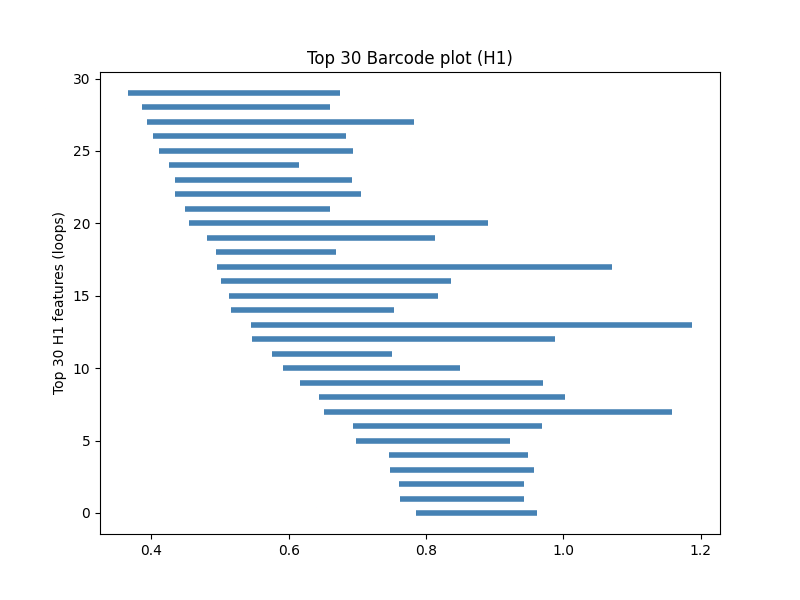

In [73]:
fig, top_lifetimes = plot_barcode_diagram(res_neural['dgms'][1])


# RIPSER on PCA of neural data

In [ ]:
from sklearn.decomposition import PCA

# fit PCA
dim = 3
pca = PCA(n_components=dim)
Y_pca = pca.fit_transform(X)
print('Percentage of variance explained by the first ', dim, ' PCs: ', pca.explained_variance_ratio_[:dim].sum().round(3))


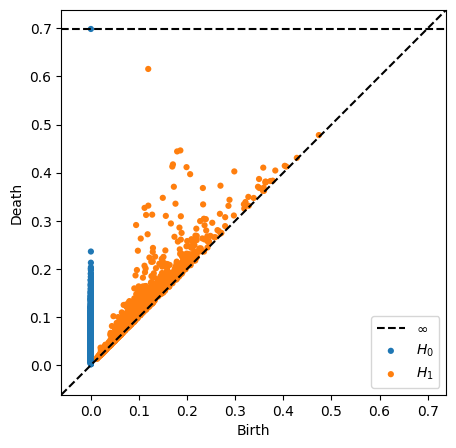

In [27]:
# Persistent homology via Vietoris–Rips ----
res = ripser(Y_pca, maxdim=1)  # H0, H1
res_pca = ripser(Y_pca, maxdim=1)  # H0, H1
fig, top_lifetimes = plot_barcode_diagram(res_pca['dgms'], 1)

# RIPSER on manifold Y of all worms


In [ ]:
for worm_num in range(5):
    Y = np.loadtxt(f'data/generated/comparable_embeddings/Y0__BunDLeNet_worm_{worm_num}')
    B = np.loadtxt(f'data/generated/comparable_embeddings/B__BunDLeNet_worm_{worm_num}')
    X = np.load(f'data/raw/c_elegans/neural_data_worm_{worm_num}.npy')[-Y.shape[0]:]
    print(X.shape, Y.shape, B.shape)

worm_0
(3122, 103) (3122, 3) (3122,)


<IPython.core.display.Javascript object>


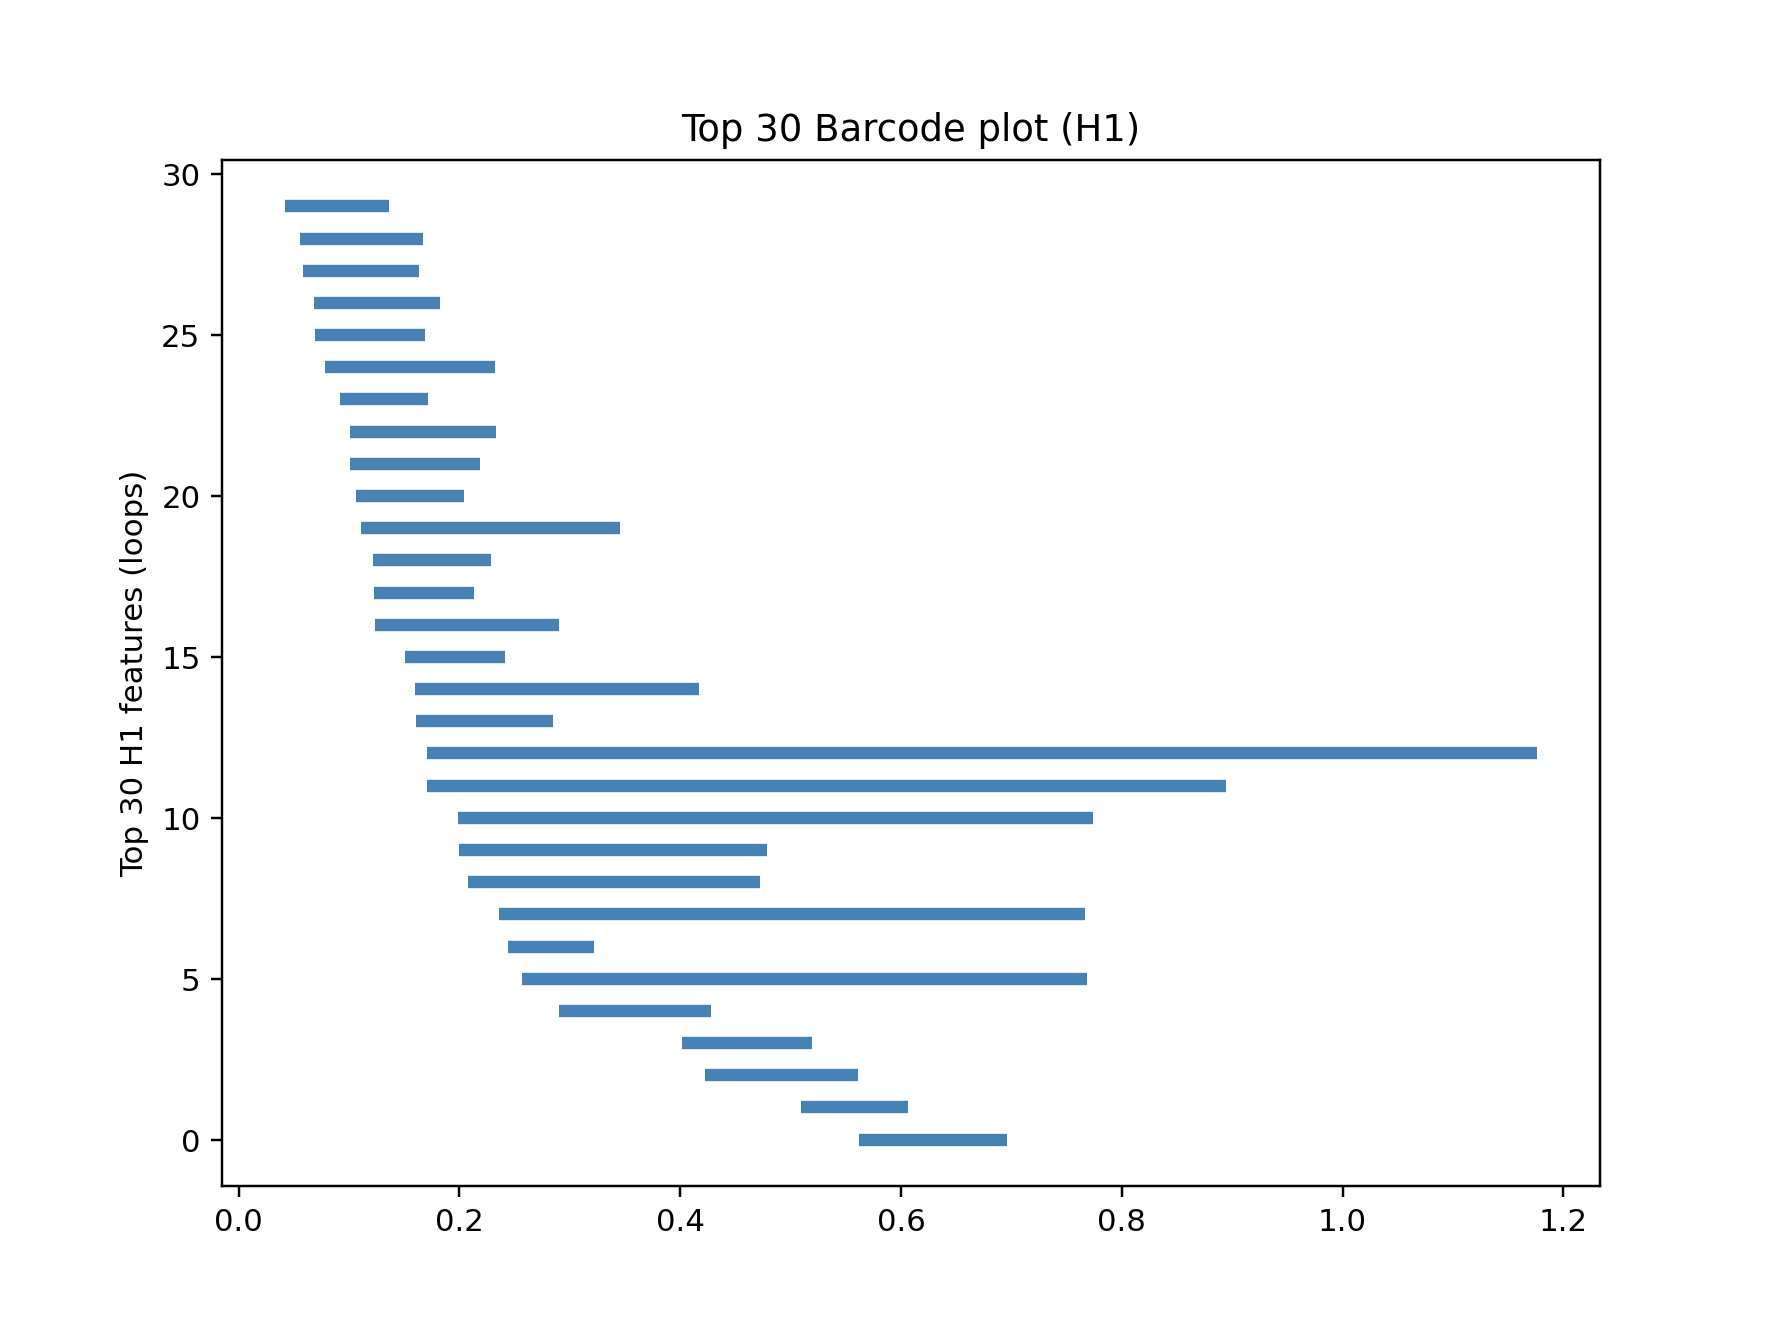

worm_1
(3119, 127) (3119, 3) (3119,)


<IPython.core.display.Javascript object>


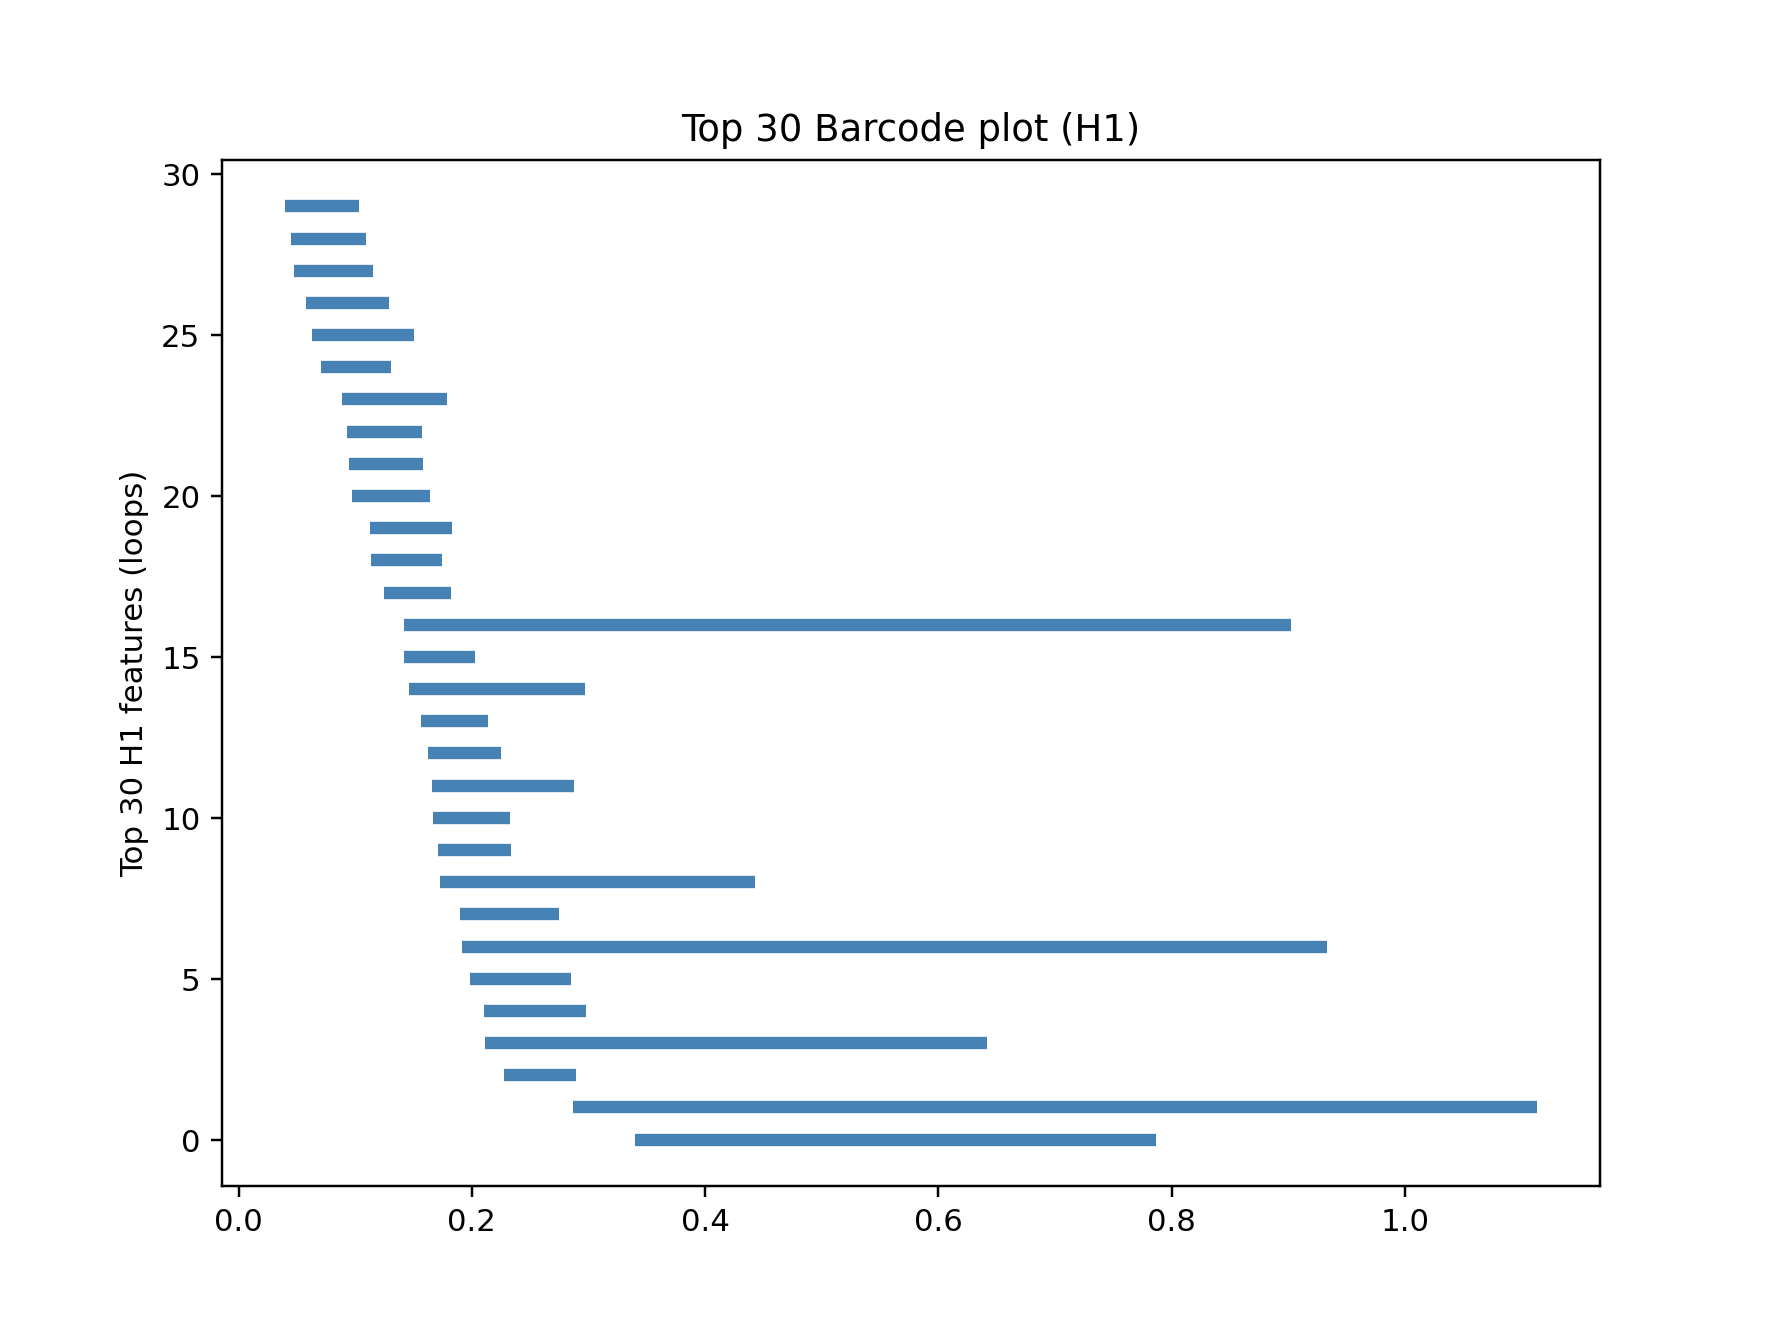

worm_2
(3044, 123) (3044, 3) (3044,)


<IPython.core.display.Javascript object>


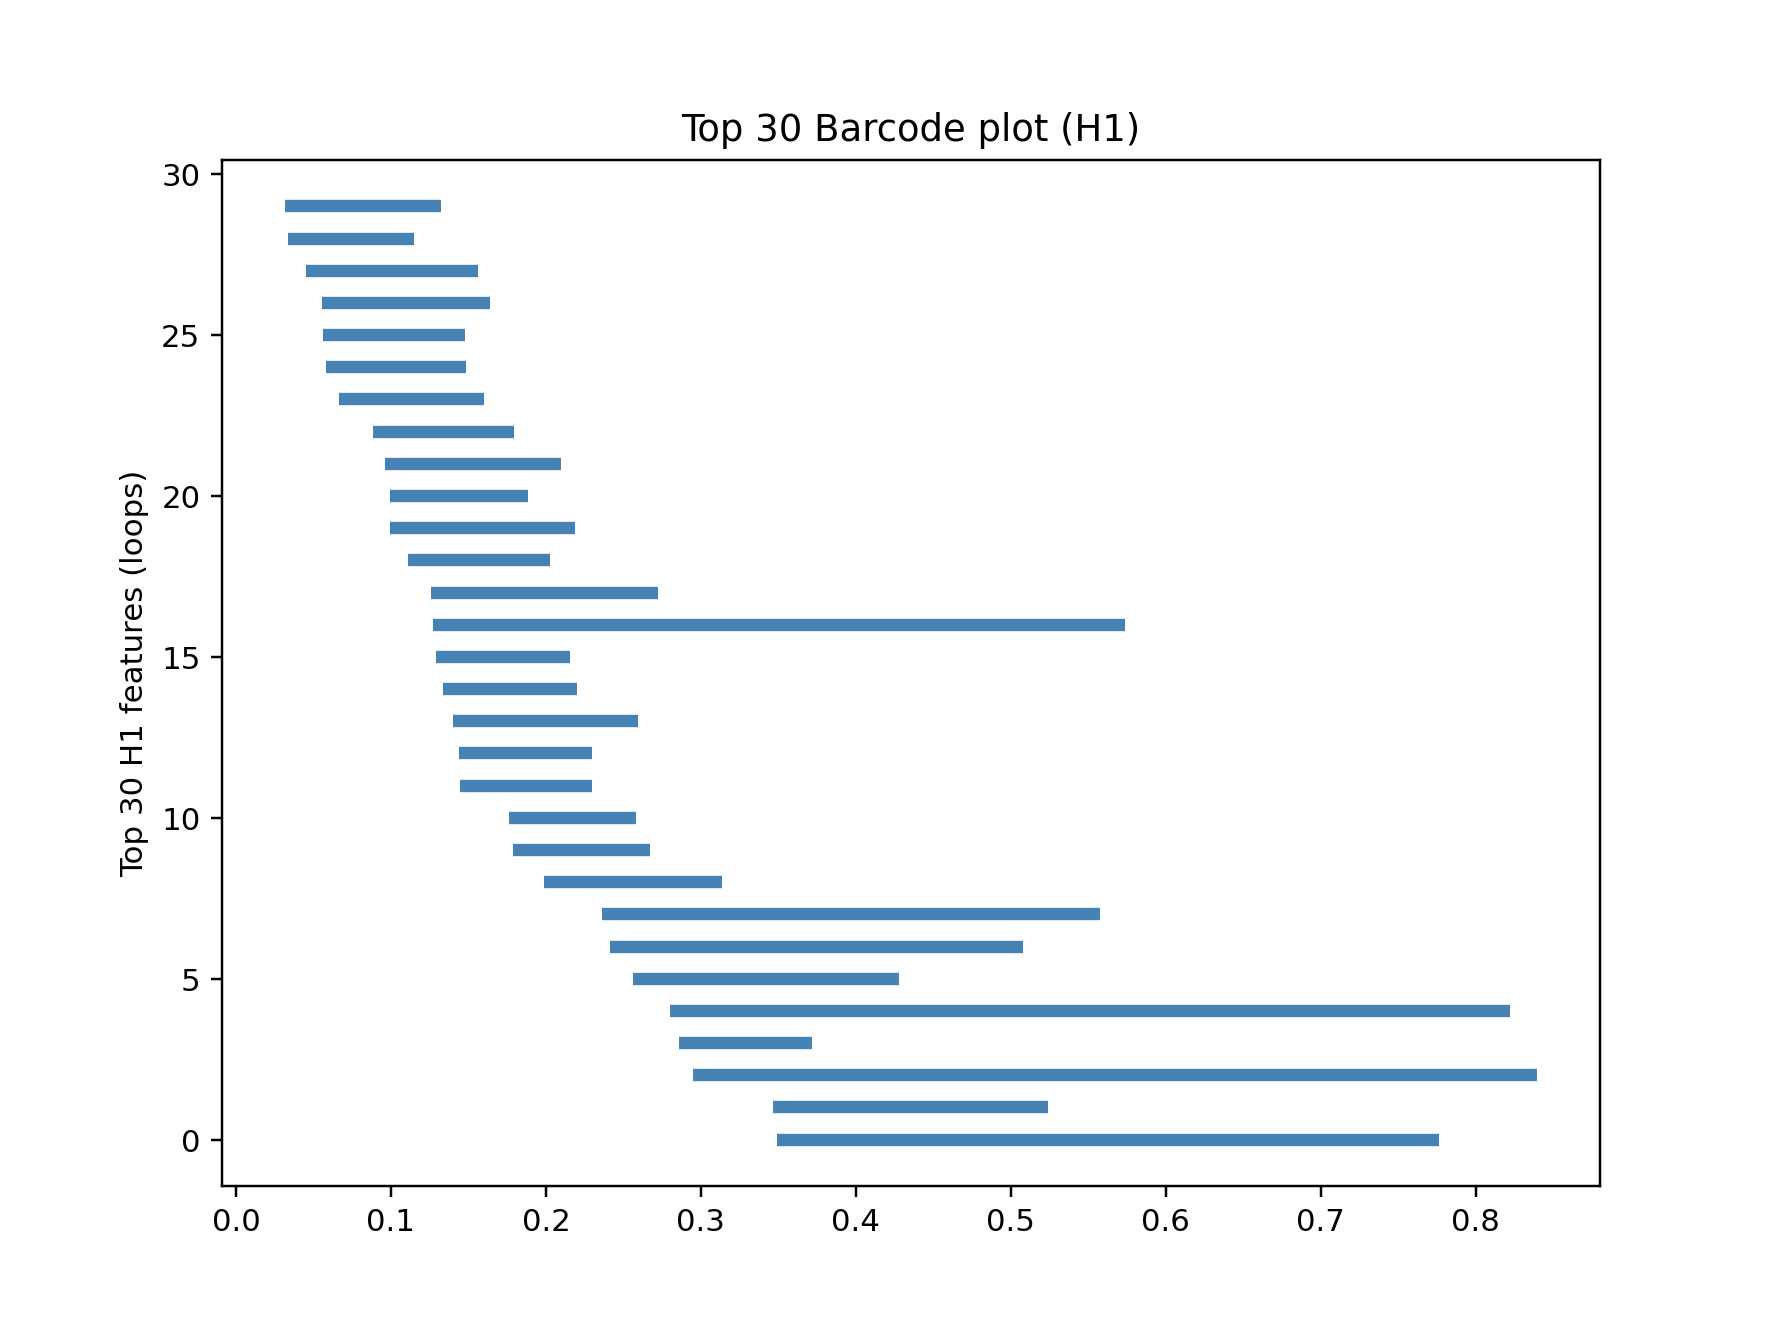

worm_3
(3296, 118) (3296, 3) (3296,)


<IPython.core.display.Javascript object>


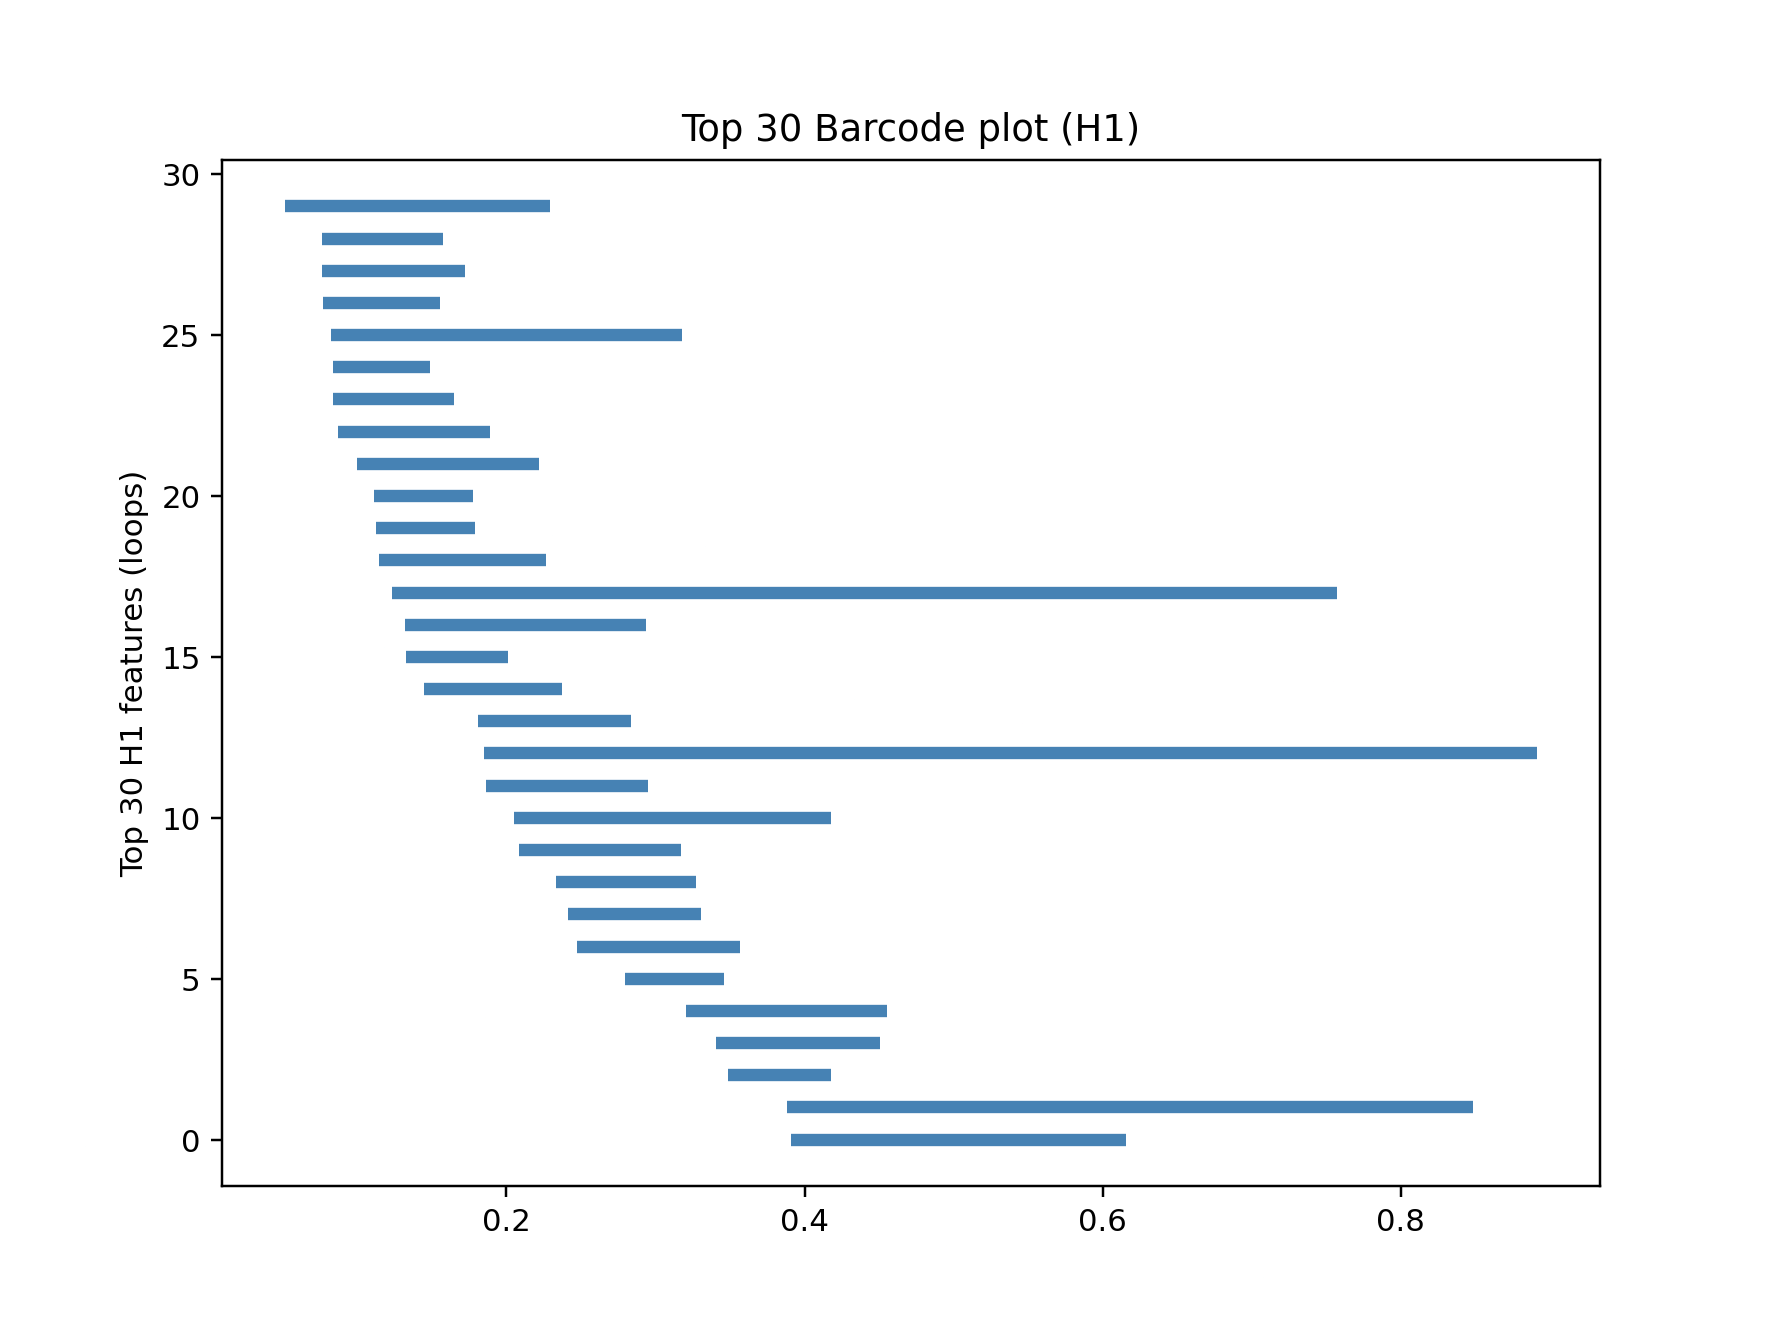

worm_4
(3006, 121) (3006, 3) (3006,)


<IPython.core.display.Javascript object>


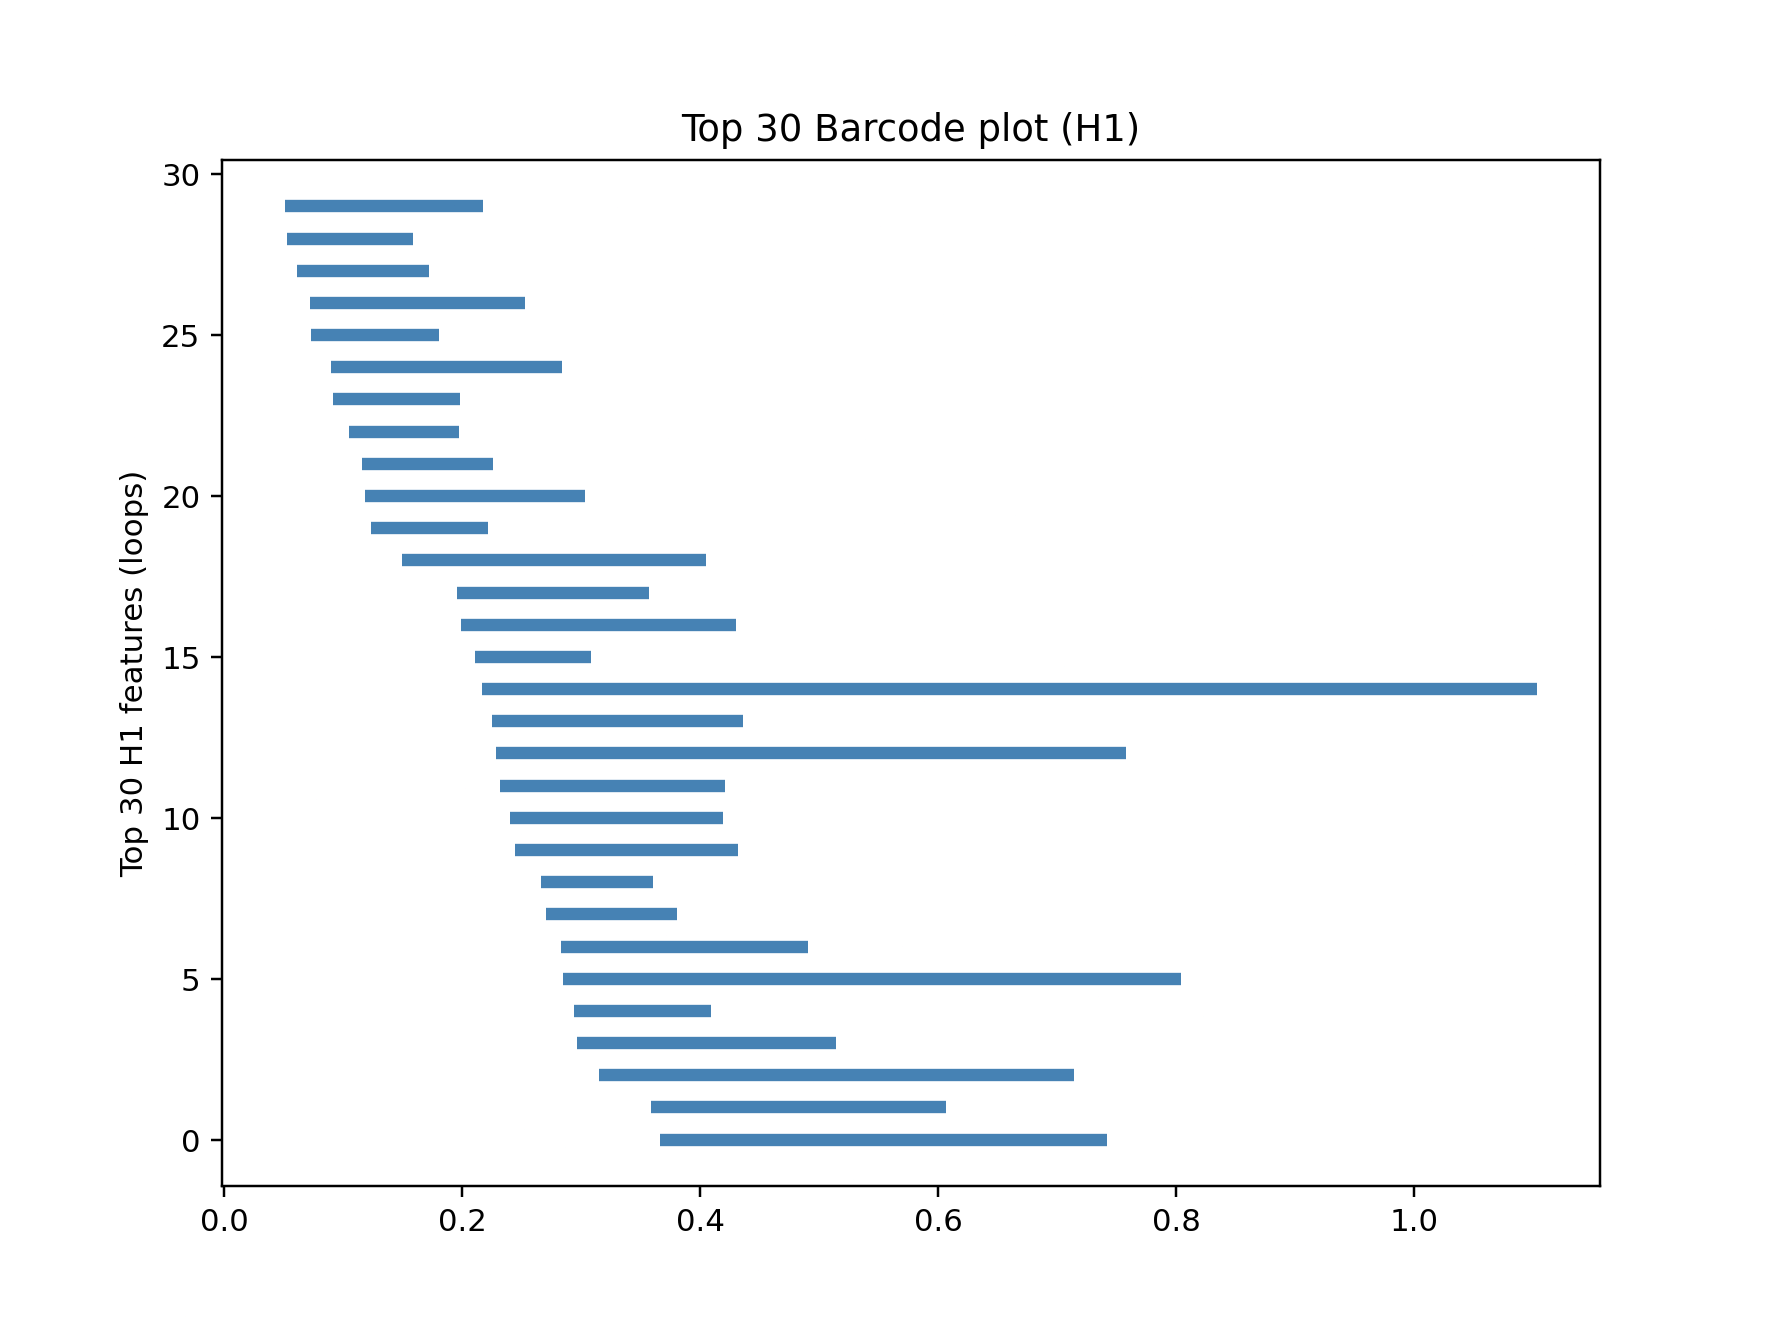

In [76]:
for worm_num in range(5):
    print(f'worm_{worm_num}')
    Y = np.loadtxt(f'data/generated/comparable_embeddings/Y0__BunDLeNet_worm_{worm_num}')
    B = np.loadtxt(f'data/generated/comparable_embeddings/B__BunDLeNet_worm_{worm_num}')
    X = np.load(f'data/raw/c_elegans/neural_data_worm_{worm_num}.npy')[-Y.shape[0]:]
    print(X.shape, Y.shape, B.shape)
    
    res = ripser(Y, maxdim=1)  # H0, H1
    fig, lifetimes = plot_barcode_diagram(res['dgms'][1])
    

# RIPSER on neural data directly of all worms


worm_0
(3006, 103) (3122,)


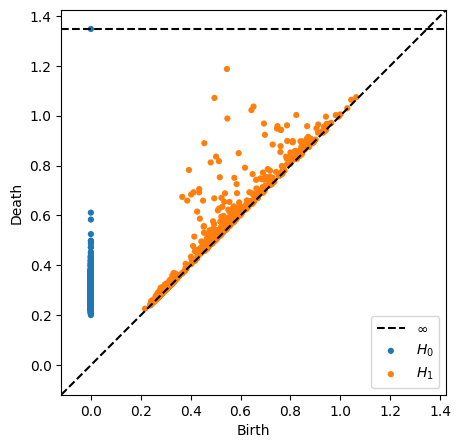

worm_1
(3006, 127) (3119,)


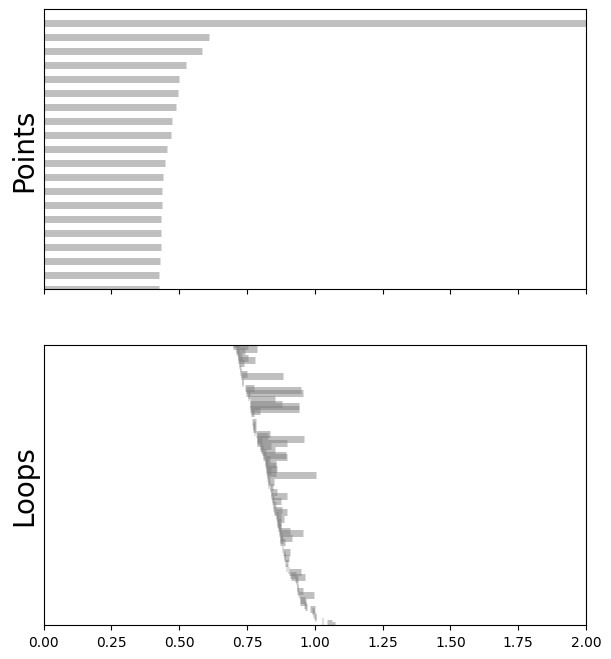

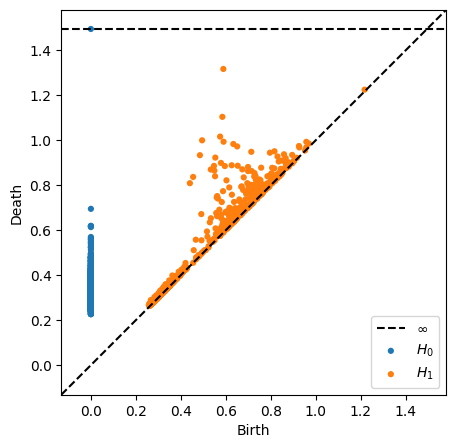

worm_2
(3006, 123) (3044,)


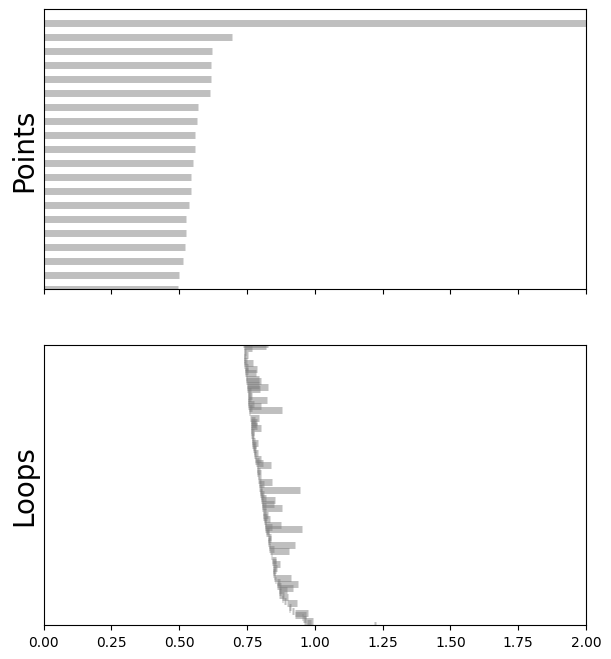

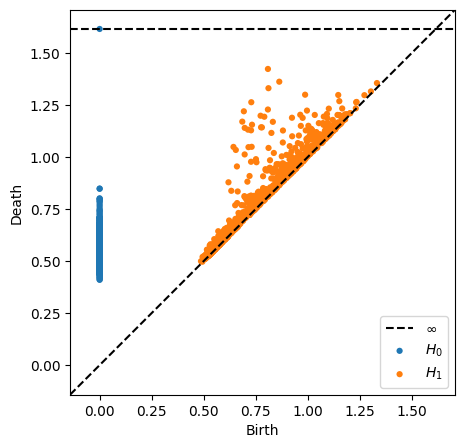

worm_3
(3006, 118) (3296,)


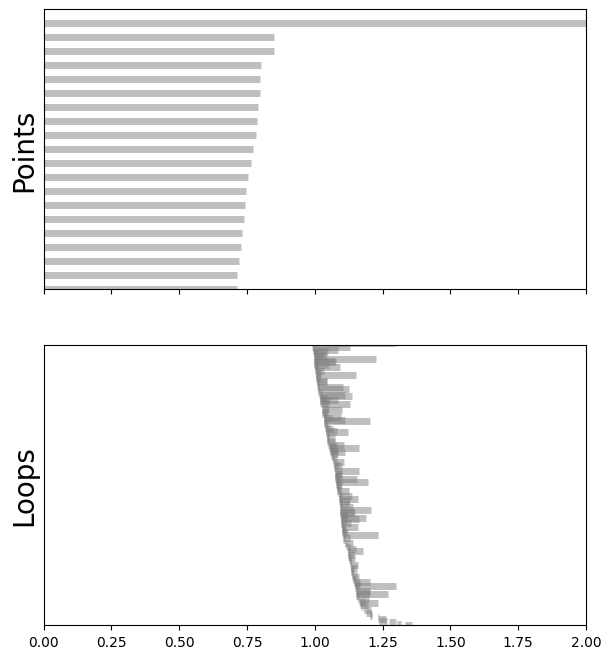

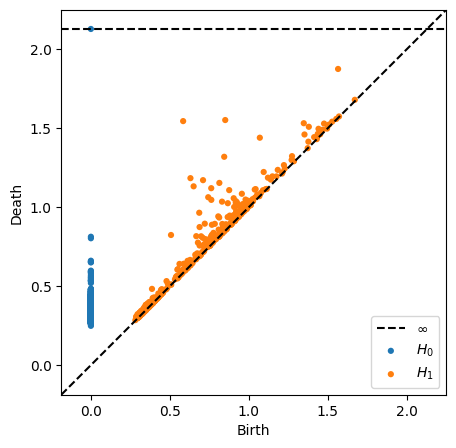

worm_4
(3006, 121) (3006,)


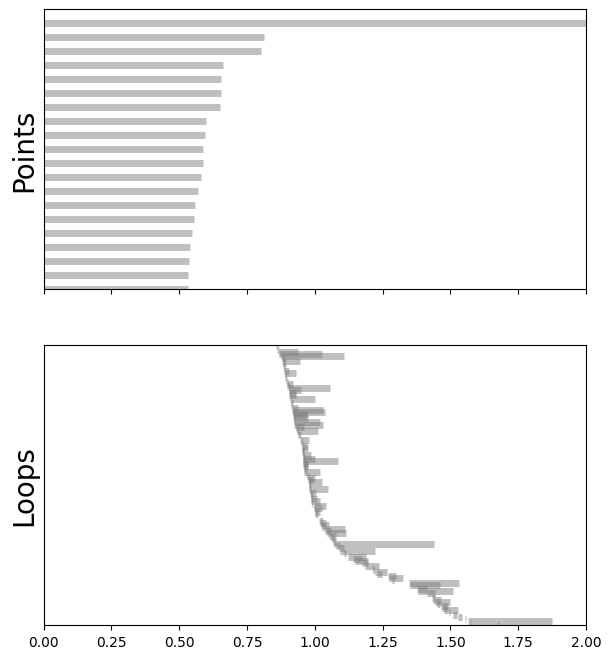

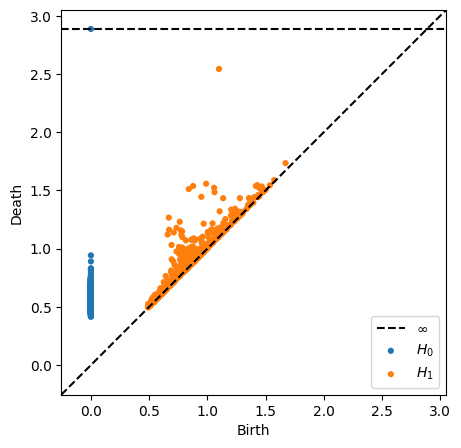

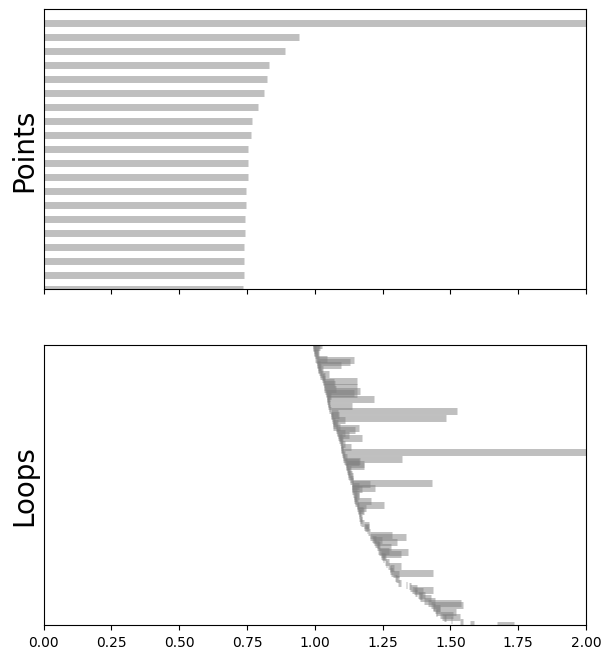

In [33]:
for worm_num in range(5):
    print(f'worm_{worm_num}')
    B = np.loadtxt(f'data/generated/comparable_embeddings/B__BunDLeNet_worm_{worm_num}')
    X = np.load(f'data/raw/c_elegans/neural_data_worm_{worm_num}.npy')[-Y.shape[0]:]
    print(X.shape, B.shape)

    res = ripser(X, maxdim=1)  # H0, H1
    diagrams = res['dgms']

    plt.figure(figsize=(6,5))
    plot_diagrams(diagrams, show=True)

    fig = plot_barcode(res, 1)

In [89]:
diagrams

[array([[ 0.        ,  0.41499469],
        [ 0.        ,  0.41715676],
        [ 0.        ,  0.42371041],
        ...,
        [ 0.        ,  0.89052594],
        [ 0.        ,  0.94277221],
        [ 0.        , 10.        ]], shape=(3006, 2)),
 array([[1.67141306, 1.73451078],
        [1.57369888, 1.58830893],
        [1.5371033 , 1.5449295 ],
        ...,
        [0.49346715, 0.52400118],
        [0.49334496, 0.52400118],
        [0.49069044, 0.49455351]], shape=(1019, 2))]

-------------------------

In [ ]:
# ---- 4) Convert to counts with a robust threshold ----
def summarize(diag, min_persistence):
    # Count features whose (death - birth) >= min_persistence
    lifetimes = diag[:,1] - diag[:,0]
    return int(np.sum(lifetimes >= min_persistence)), lifetimes

# Pick a data-driven threshold: e.g., 90th percentile of H_k lifetimes (noise rejection)
def auto_threshold(diag, q=0.99):
    if len(diag)==0: return 0.0
    lt = diag[:,1]-diag[:,0]
    return float(np.quantile(lt, q))

# H0: components/branches (ignore the single largest lifetime which represents the main component merging last)
H0 = diagrams[0]
H1 = diagrams[1]
H2 = diagrams[2] if len(diagrams) > 2 else np.empty((0,2))

thr0 = auto_threshold(H0)
thr1 = auto_threshold(H1)
thr2 = auto_threshold(H2)

# Count robust H1 (loops) and H2 (voids)
loops_count, loops_lifetimes = summarize(H1, min_persistence=thr1)
voids_count, voids_lifetimes = summarize(H2, min_persistence=thr2)

# For H0 (components/“branches”): count robust H0 features excluding the single most persistent one
if len(H0) > 0:
    h0_life = H0[:,1]-H0[:,0]
    main_idx = np.argmax(h0_life)
    mask = np.ones(len(H0), dtype=bool); mask[main_idx] = False
    branches_count = int(np.sum((h0_life[mask] >= thr0)))
else:
    branches_count = 0

print(f"Estimated branches/components (H0, robust): {branches_count}")
print(f"Estimated loops (H1, robust): {loops_count}")
print(f"Estimated voids (H2, robust): {voids_count}")


# Optional: also report counts with a fixed threshold (e.g., 0.05) if you prefer
fixed_thr = 0.05
def count_fixed(diag, thr):
    return int(np.sum((diag[:,1]-diag[:,0]) >= thr)) if len(diag)>0 else 0

branches_fixed = count_fixed(H0[np.arange(len(H0))!=np.argmax(H0[:,1]-H0[:,0])], fixed_thr)
loops_fixed    = count_fixed(H1, fixed_thr)
voids_fixed    = count_fixed(H2, fixed_thr)
print(f"(Fixed thr={fixed_thr}) H0 branches: {branches_fixed}, H1 loops: {loops_fixed}, H2 voids: {voids_fixed}")


In [ ]:
!pip install kmapper scikit-learn numpy networkx matplotlib giotto-tda


In [ ]:
Y = np.loadtxt('/content/Y0__BunDLeNet_worm_0')
B = np.loadtxt('/content/B__BunDLeNet_worm_0')
X = np.load('/content/neural_data_worm_0.npy')[-3122:]
print(X.shape, Y.shape, B.shape)

# ---- 3. Cover on filter Y ----
cover = CubicalCover(n_intervals=10, overlap_frac=0.3)

# ---- 4. Clustering on original X (DBSCAN) ----
clusterer = DBSCAN() # (eps=0.5, min_samples=3)

# ---- 5. Mapper pipeline ----
# Note: we pass X as input, and Y separately as filter
from gtda.mapper import make_mapper_pipeline
mapper_pipe = make_mapper_pipeline(
    filter_func=None,   # we already computed Y
    cover=cover,
    clusterer=clusterer,
    verbose=True
)

graph = mapper_pipe.fit_transform(X=X, y=Y)

# ---- 6. Visualize Mapper graph ----
fig = plot_static_mapper_graph(mapper_pipe, X, B)
fig.show()

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from gtda.mapper import make_mapper_pipeline, CubicalCover
from gtda.mapper import plot_static_mapper_graph

# ---- 1. Simulate original high-dimensional data X ----
# Let's make a toy dataset: branching structure in 100D
n = 300
t = np.linspace(0, 1, n//3)

# trunk in 100D
trunk = np.zeros((n//3, 100))
trunk[:, 0] = t

# branch1
branch1 = np.zeros((n//3, 100))
branch1[:, 0] = 1 + t
branch1[:, 1] = t

# branch2
branch2 = np.zeros((n//3, 100))
branch2[:, 0] = 1 + t
branch2[:, 1] = -t

X = np.vstack([trunk, branch1, branch2])  # shape (300, 100)

print("Shape of X:", X.shape)

# ---- 2. Define the filter function Y (here: PCA projection to 2D) ----
pca = PCA(n_components=2)
Y = pca.fit_transform(X)

# ---- 3. Cover on filter Y ----
cover = CubicalCover(n_intervals=10, overlap_frac=0.3)

# ---- 4. Clustering on original X (DBSCAN) ----
clusterer = DBSCAN(eps=0.5, min_samples=3)

# ---- 5. Mapper pipeline ----
# Note: we pass X as input, and Y separately as filter
from gtda.mapper import make_mapper_pipeline
mapper_pipe = make_mapper_pipeline(
    filter_func=None,   # we already computed Y
    cover=cover,
    clusterer=clusterer,
    verbose=True
)

graph = mapper_pipe.fit_transform(X=X, y=Y)

# ---- 6. Visualize Mapper graph ----
fig = plot_static_mapper_graph(mapper_pipe, X, Y)
fig.show()
